# MSCS 634 Lab 5: Hierarchical and DBSCAN Clustering

**Name:** Bikram Lamsal  
**Course Title:** MSCS 634 - Advanced Big Data and Data Mining  
**Lab Assignment Title:** Lab 5 - Hierarchical and DBSCAN Clustering Using the Wine Dataset

## Step 1: Data Preparation and Exploration

This section loads the Wine dataset from `sklearn.datasets`, examines the feature table with `.head()`, `.info()`, and `.describe()`, checks class distribution, and standardizes the features before clustering.

In [1]:
import io
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.metrics import completeness_score, homogeneity_score, silhouette_score
from sklearn.preprocessing import StandardScaler

plt.style.use("seaborn-v0_8-whitegrid")

Matplotlib is building the font cache; this may take a moment.


In [2]:
wine = load_wine()

X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target, name="target")

wine_df = X.copy()
wine_df["target"] = y
wine_df["class_name"] = y.map(dict(enumerate(wine.target_names)))

print(f"Dataset shape: {X.shape[0]} rows and {X.shape[1]} features")
print("Target classes:", list(wine.target_names))
wine_df.head()

Dataset shape: 178 rows and 13 features
Target classes: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,class_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


In [3]:
buffer = io.StringIO()
X.info(buf=buffer)
print(buffer.getvalue())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: fl

In [4]:
feature_summary = X.describe().T[["mean", "std", "min", "max"]]
feature_summary

,mean,std,min,max
alcohol,13.000618,0.811827,11.03,14.83
malic_acid,2.336348,1.117146,0.74,5.80
ash,2.366517,0.274344,1.36,3.23
alcalinity_of_ash,19.494944,3.339564,10.60,30.00
magnesium,99.741573,14.282484,70.00,162.00
total_phenols,2.295112,0.625851,0.98,3.88
flavanoids,2.029270,0.998859,0.34,5.08
nonflavanoid_phenols,0.361854,0.124453,0.13,0.66
proanthocyanins,1.590899,0.572359,0.41,3.58
color_intensity,5.058090,2.318286,1.28,13.00


In [5]:
class_distribution = (
    wine_df["class_name"]
    .value_counts()
    .rename_axis("class_name")
    .reset_index(name="count")
)
class_distribution

,class_name,count
0,class_1,71
1,class_0,59
2,class_2,48


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

scaled_summary = pd.DataFrame(X_scaled, columns=wine.feature_names).describe().T[["mean", "std", "min", "max"]]
scaled_summary

,mean,std,min,max
alcohol,7.943708e-15,1.002821,-2.434235,2.259772
malic_acid,3.592632e-16,1.002821,-1.432983,3.109192
ash,-4.066660e-15,1.002821,-3.679162,3.156325
alcalinity_of_ash,-7.983626e-17,1.002821,-2.671018,3.154511
magnesium,-7.983626e-17,1.002821,-2.088255,4.371372
total_phenols,-3.991813e-17,1.002821,-2.107246,2.539515
flavanoids,9.979533e-16,1.002821,-1.695971,3.062832
nonflavanoid_phenols,-5.588538e-16,1.002821,-1.868234,2.402403
proanthocyanins,-1.656602e-15,1.002821,-2.069034,3.485073
color_intensity,-3.442939e-16,1.002821,-1.634288,3.435432


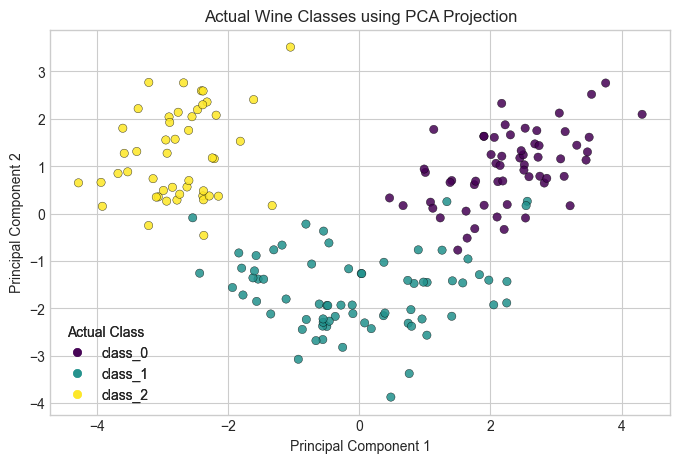

In [7]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    cmap="viridis",
    edgecolor="black",
    linewidth=0.3,
    alpha=0.85
)
ax.set_title("Actual Wine Classes using PCA Projection")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
legend = ax.legend(
    handles=scatter.legend_elements()[0],
    labels=list(wine.target_names),
    title="Actual Class"
)
ax.add_artist(legend)
plt.show()

### Data Preparation Interpretation

The Wine dataset contains 178 records, 13 numeric chemical features, and 3 known wine classes. The `.info()` output confirms that all feature columns are numeric and non-null, so no missing-value imputation is required. The `.describe()` output shows that the original feature ranges differ substantially, especially for features such as `proline`, `magnesium`, and `color_intensity`. Because both hierarchical clustering and DBSCAN depend on distance calculations, standardization is necessary so that large-scale features do not dominate the clustering process.

The PCA reference plot provides visual context for the true class structure. It shows that the wine classes have visible separation in the first two principal components, but they are not perfectly isolated. This matters because clustering algorithms are trained without using the class labels, so imperfect separation can reduce metric scores even when the clusters are meaningful.

## Step 2: Hierarchical Clustering

Agglomerative Hierarchical Clustering is tested with several values of `n_clusters`. Ward linkage is used because it tends to form compact clusters by minimizing within-cluster variance.

In [8]:
def clustering_metrics(true_labels, cluster_labels):
    unique_labels = set(cluster_labels)
    if len(unique_labels) > 1 and len(unique_labels) < len(cluster_labels):
        silhouette = silhouette_score(X_scaled, cluster_labels)
    else:
        silhouette = np.nan

    return {
        "silhouette_score": silhouette,
        "homogeneity_score": homogeneity_score(true_labels, cluster_labels),
        "completeness_score": completeness_score(true_labels, cluster_labels),
    }


hierarchical_results = []
hierarchical_labels_by_k = {}

for n_clusters in [2, 3, 4, 5, 6]:
    model = AgglomerativeClustering(n_clusters=n_clusters, linkage="ward")
    labels = model.fit_predict(X_scaled)
    hierarchical_labels_by_k[n_clusters] = labels

    result = {
        "n_clusters": n_clusters,
        "formed_clusters": len(set(labels)),
        **clustering_metrics(y, labels),
    }
    hierarchical_results.append(result)

hierarchical_metrics = pd.DataFrame(hierarchical_results)
hierarchical_metrics

,n_clusters,formed_clusters,silhouette_score,homogeneity_score,completeness_score
0,2,2,0.267013,0.444094,0.774489
1,3,3,0.277444,0.790429,0.782541
2,4,4,0.225837,0.790429,0.649028
3,5,5,0.186742,0.810589,0.576247
4,6,6,0.179666,0.834839,0.552993


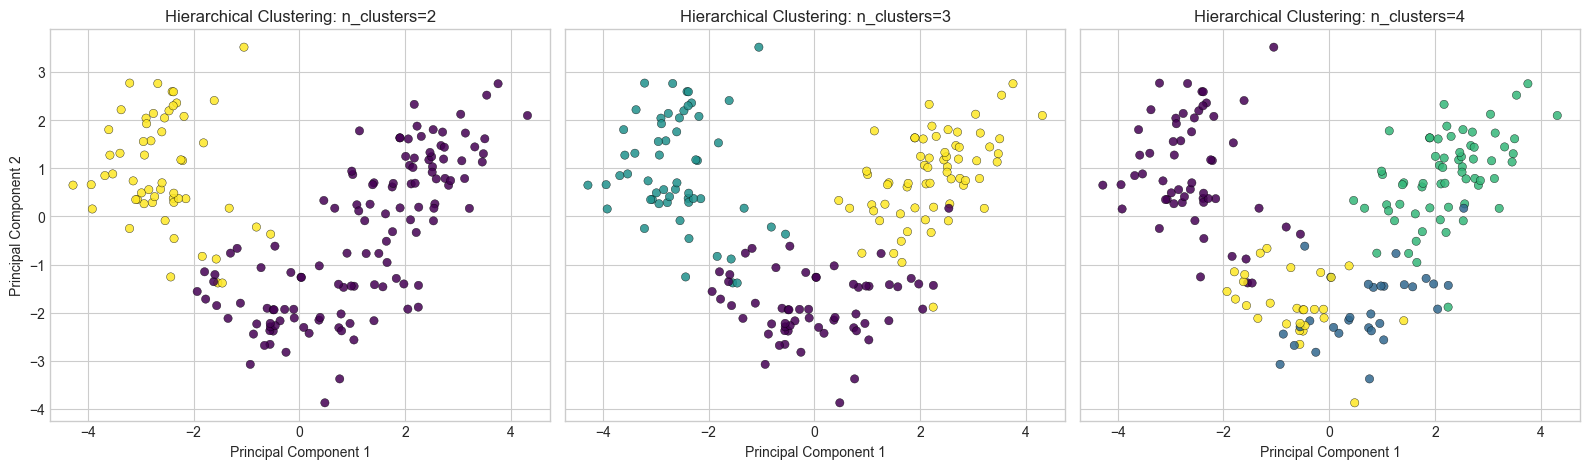

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharex=True, sharey=True)

for ax, n_clusters in zip(axes, [2, 3, 4]):
    labels = hierarchical_labels_by_k[n_clusters]
    scatter = ax.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=labels,
        cmap="viridis",
        edgecolor="black",
        linewidth=0.3,
        alpha=0.85
    )
    ax.set_title(f"Hierarchical Clustering: n_clusters={n_clusters}")
    ax.set_xlabel("Principal Component 1")

axes[0].set_ylabel("Principal Component 2")
plt.tight_layout()
plt.show()

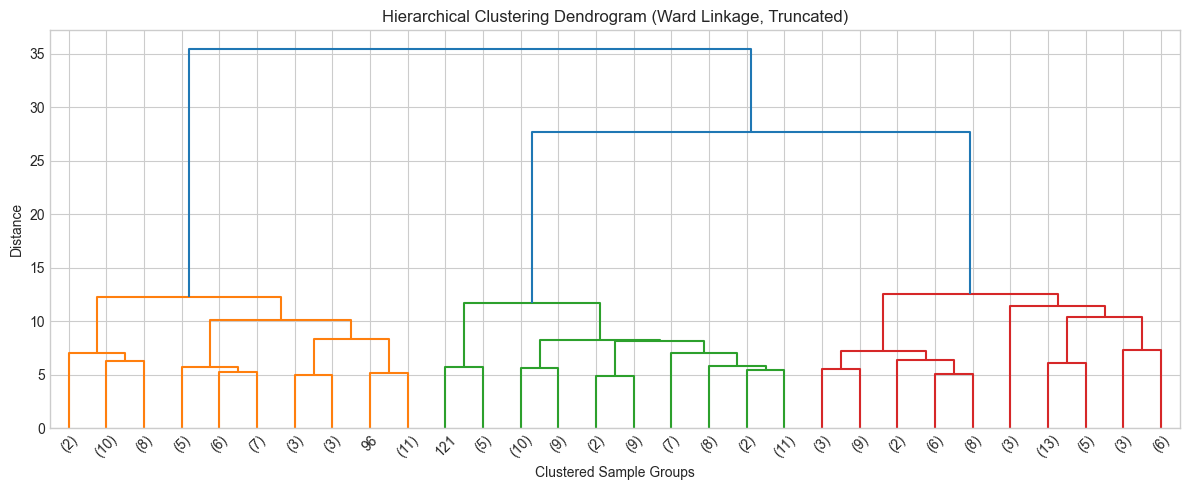

In [10]:
linked = linkage(X_scaled, method="ward")

fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(
    linked,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=45,
    leaf_font_size=10,
    ax=ax
)
ax.set_title("Hierarchical Clustering Dendrogram (Ward Linkage, Truncated)")
ax.set_xlabel("Clustered Sample Groups")
ax.set_ylabel("Distance")
plt.tight_layout()
plt.show()

### Hierarchical Clustering Interpretation

The hierarchical results show that `n_clusters=3` provides the strongest balance for this dataset. It has the highest Silhouette Score among the tested cluster counts and also strong homogeneity and completeness scores. Silhouette Score measures how well each point fits within its assigned cluster compared with nearby clusters, while homogeneity and completeness compare the clusters with the known Wine class labels. The stronger scores at `n_clusters=3` make sense because the dataset contains three actual wine classes.

The scatter plots show that changing `n_clusters` changes how the PCA space is partitioned. With too few clusters, distinct groups are merged together. With too many clusters, existing groups are split into smaller pieces. The dendrogram supports this interpretation by showing how observations merge as the distance threshold increases. Larger vertical gaps near the top indicate bigger jumps in linkage distance, which suggests a smaller number of major clusters is reasonable for this dataset.

## Step 3: DBSCAN Clustering

DBSCAN is tested with multiple `eps` and `min_samples` values. DBSCAN can identify noise points, which are labeled as `-1`. The parameter grid shows how sensitive DBSCAN is to density settings.

In [11]:
dbscan_parameter_grid = [
    (1.5, 3),
    (1.8, 3),
    (2.0, 5),
    (2.2, 3),
    (2.2, 5),
    (2.5, 10),
    (3.0, 3),
]

dbscan_results = []
dbscan_labels_by_params = {}

for eps, min_samples in dbscan_parameter_grid:
    model = DBSCAN(eps=eps, min_samples=min_samples)
    labels = model.fit_predict(X_scaled)
    dbscan_labels_by_params[(eps, min_samples)] = labels

    non_noise_clusters = set(labels) - {-1}
    noise_points = int(np.sum(labels == -1))
    result = {
        "eps": eps,
        "min_samples": min_samples,
        "formed_clusters": len(non_noise_clusters),
        "noise_points": noise_points,
        "noise_percent": noise_points / len(labels),
        **clustering_metrics(y, labels),
    }
    dbscan_results.append(result)

dbscan_metrics = pd.DataFrame(dbscan_results)
dbscan_metrics

,eps,min_samples,formed_clusters,noise_points,noise_percent,silhouette_score,homogeneity_score,completeness_score
0,1.5,3,8,147,0.825843,-0.276769,0.189179,0.251015
1,1.8,3,8,90,0.505618,-0.032552,0.532193,0.374657
2,2.0,5,5,85,0.477528,-0.032906,0.362354,0.324734
3,2.2,3,3,44,0.247191,-0.003857,0.485755,0.480773
4,2.2,5,2,55,0.308989,0.142678,0.410410,0.428216
5,2.5,10,2,32,0.179775,0.204389,0.504468,0.560379
6,3.0,3,2,7,0.039326,0.191097,0.031093,0.134726


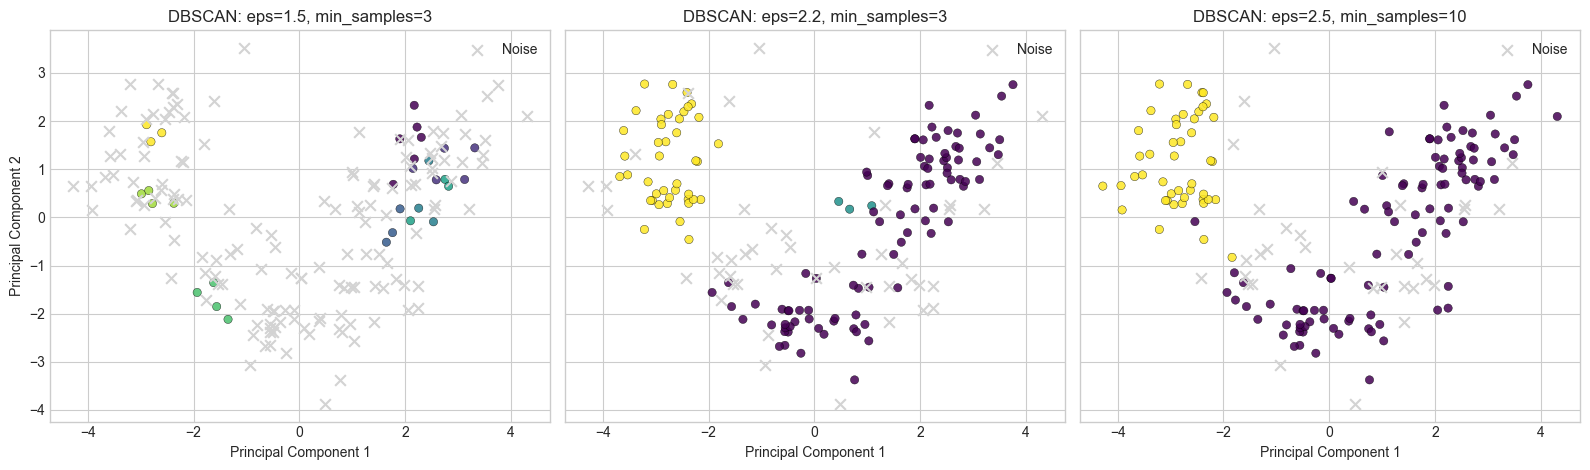

In [12]:
def plot_dbscan(ax, labels, title):
    non_noise_mask = labels != -1
    noise_mask = labels == -1

    ax.scatter(
        X_pca[non_noise_mask, 0],
        X_pca[non_noise_mask, 1],
        c=labels[non_noise_mask],
        cmap="viridis",
        edgecolor="black",
        linewidth=0.3,
        alpha=0.85
    )
    ax.scatter(
        X_pca[noise_mask, 0],
        X_pca[noise_mask, 1],
        color="lightgray",
        marker="x",
        s=60,
        label="Noise"
    )
    ax.set_title(title)
    ax.set_xlabel("Principal Component 1")
    ax.legend(loc="best")


fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharex=True, sharey=True)
examples = [(1.5, 3), (2.2, 3), (2.5, 10)]

for ax, params in zip(axes, examples):
    labels = dbscan_labels_by_params[params]
    eps, min_samples = params
    plot_dbscan(ax, labels, f"DBSCAN: eps={eps}, min_samples={min_samples}")

axes[0].set_ylabel("Principal Component 2")
plt.tight_layout()
plt.show()

### DBSCAN Interpretation

DBSCAN was much more sensitive to parameter choice than hierarchical clustering. The `eps` parameter controls how close points must be to count as neighbors. Small `eps` values classified many observations as noise because the neighborhood radius was too strict. Larger `eps` values reduced noise but often merged observations into too few broad clusters. The `min_samples` parameter controls how many nearby points are required to form a dense region; increasing it makes DBSCAN more conservative and can increase the number of noise points.

The setting `eps=2.5` and `min_samples=10` produced the strongest DBSCAN balance among the tested settings, but it still formed only two non-noise clusters and did not match the three Wine classes as well as hierarchical clustering. The PCA plots make this visible: DBSCAN identifies noise points and density regions, but the standardized Wine classes appear more like compact groups than irregular density-separated regions. This explains why DBSCAN is useful for demonstrating noise detection here but is not the best fit for recovering the known class structure.

## Step 4: Analysis and Insights

This section compares the best hierarchical result with the most useful DBSCAN result from the tested parameter settings.

In [13]:
best_hierarchical = hierarchical_metrics.loc[hierarchical_metrics["silhouette_score"].idxmax()].copy()
selected_dbscan = dbscan_metrics.loc[(dbscan_metrics["eps"] == 2.5) & (dbscan_metrics["min_samples"] == 10)].iloc[0].copy()

comparison = pd.DataFrame([
    {
        "algorithm": "Agglomerative Hierarchical",
        "parameters": f"n_clusters={int(best_hierarchical['n_clusters'])}",
        "formed_clusters": int(best_hierarchical["formed_clusters"]),
        "noise_points": 0,
        "silhouette_score": best_hierarchical["silhouette_score"],
        "homogeneity_score": best_hierarchical["homogeneity_score"],
        "completeness_score": best_hierarchical["completeness_score"],
    },
    {
        "algorithm": "DBSCAN",
        "parameters": "eps=2.5, min_samples=10",
        "formed_clusters": int(selected_dbscan["formed_clusters"]),
        "noise_points": int(selected_dbscan["noise_points"]),
        "silhouette_score": selected_dbscan["silhouette_score"],
        "homogeneity_score": selected_dbscan["homogeneity_score"],
        "completeness_score": selected_dbscan["completeness_score"],
    },
])
comparison

,algorithm,parameters,formed_clusters,noise_points,silhouette_score,homogeneity_score,completeness_score
0,Agglomerative Hierarchical,n_clusters=3,3,0,0.277444,0.790429,0.782541
1,DBSCAN,"eps=2.5, min_samples=10",2,32,0.204389,0.504468,0.560379


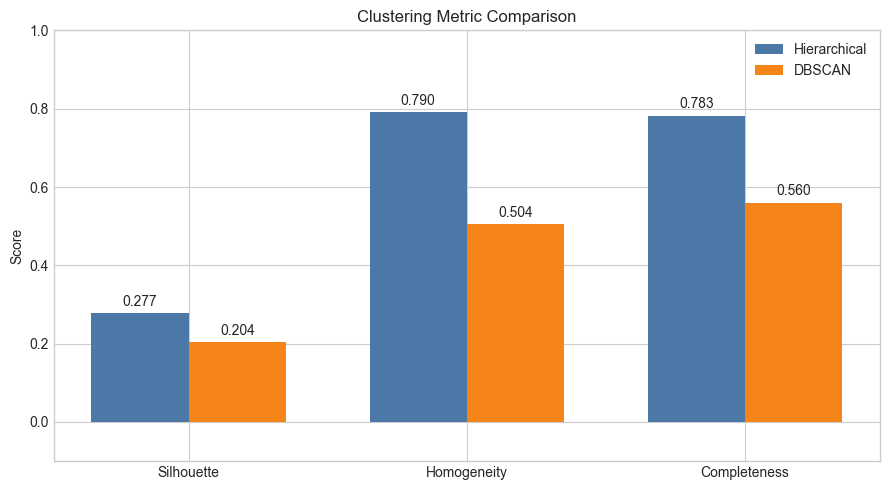

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
metric_columns = ["silhouette_score", "homogeneity_score", "completeness_score"]
x = np.arange(len(metric_columns))
bar_width = 0.35

ax.bar(
    x - bar_width / 2,
    comparison.loc[0, metric_columns],
    width=bar_width,
    label="Hierarchical",
    color="#4C78A8"
)
ax.bar(
    x + bar_width / 2,
    comparison.loc[1, metric_columns],
    width=bar_width,
    label="DBSCAN",
    color="#F58518"
)
ax.set_title("Clustering Metric Comparison")
ax.set_xticks(x)
ax.set_xticklabels(["Silhouette", "Homogeneity", "Completeness"])
ax.set_ylabel("Score")
ax.set_ylim(-0.1, 1.0)
ax.legend()

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.tight_layout()
plt.show()

### Final Analysis

- Hierarchical clustering performed better for the standardized Wine dataset. With `n_clusters=3`, it produced the best Silhouette Score among the tested hierarchical settings and aligned well with the known three-class structure.
- The hierarchical dendrogram helped confirm that the dataset has a small number of major groups. This makes hierarchical clustering useful when the analyst wants to inspect cluster structure before selecting a final number of clusters.
- DBSCAN was useful for showing density-based clustering behavior, especially how noise points change as `eps` and `min_samples` change. However, it did not recover the Wine classes as effectively as hierarchical clustering.
- Smaller DBSCAN `eps` values were too restrictive and labeled many records as noise. Larger `eps` values reduced noise but merged clusters together. Increasing `min_samples` made the algorithm more conservative and often increased the number of noise points.
- Hierarchical clustering is preferable here when the expected number of clusters is known or can be inferred from a dendrogram. DBSCAN is preferable when the data has irregular density-separated clusters and when identifying noise or outliers is important.
- The metric comparison shows that hierarchical clustering produced stronger agreement with the known labels. DBSCAN's lower homogeneity and completeness scores indicate that its density-based clusters did not map cleanly onto the three wine classes.
- The main insight is that clustering performance depends heavily on whether the algorithm assumptions match the dataset structure. The Wine data is more naturally represented by compact groups than by density-separated regions with clear noise points.